## Section 1: Problem Definition

### 1.1: Title

> House Price Prediction Dataset

### 1.2: Author

> James Kilonzo

### 1.3: Objective

> Solution:
>> Machine learning model for predicting the price of a house based on Boston's housing data.

> Solution Impact:
>> Enables risk management for tenants in real estate businesses.

### 1.4: Project Dataset Source

> House Price Prediction Dataset (Scikit-learn)

### 1.5: Dataset Link

> Dataset Link (CMU University Website): https://lib.stat.cmu.edu/datasets/boston

## Section 2: Data Acquisition

### Step 2.1: Import necessary libraries

In [ ]:
!pip install imbalanced-learn scikit-learn xgboost

In [ ]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set Up Visualization Style
%matplotlib inline
sns.set_style('whitegrid')

### Step 2.2: Load the Boston House Price Dataset from URL

> What I did

>> Loaded the Boston dataset from the CMU URL and reconstructed the feature matrix and target from the file’s alternating-row format.

>> Assigned human‑readable column names and added the price column.

> Why this is necessary

>> Correctly parsing the raw file ensures features align with the target. Any misalignment would invalidate training and evaluation.

>> Labeled columns make EDA, feature selection, and downstream code clearer and less error prone.

In [ ]:
# Dataset URL
house_price_dataset_url = "http://lib.stat.cmu.edu/datasets/boston"
data_url = house_price_dataset_url

# Load raw dataset
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Reconstruct features and target
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Define feature labels
feature_names = [
    "CRIM",     # per capita crime rate by town
    "ZN",       # proportion of residential land zoned for lots over 25,000 sq.ft.
    "INDUS",    # proportion of non-retail business acres per town
    "CHAS",     # Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
    "NOX",      # nitric oxides concentration (parts per 10 million)
    "RM",       # average number of rooms per dwelling
    "AGE",      # proportion of owner-occupied units built prior to 1940
    "DIS",      # weighted distances to five Boston employment centres
    "RAD",      # index of accessibility to radial highways
    "TAX",      # full-value property-tax rate per $10,000
    "PTRATIO",  # pupil-teacher ratio by town
    "B",        # 1000(Bk - 0.63)^2 where Bk is proportion of Black residents
    "LSTAT"     # % lower status of the population
]

# Convert to DataFrame with labels
df = pd.DataFrame(data, columns=feature_names)

# Change "MEDV" to "price"
df["price"] = target  # add target column

# Display first few rows with labels
print("Boston Housing dataset preview with labels:")
print("-----------------------------------------------------------------------")
print(df.head())
print("-----------------------------------------------------------------------")


Boston Housing dataset preview with labels:
-----------------------------------------------------------------------
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  price  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  
-----------------------------------------------------------------------


### Step 2.3: Observe the loaded Pandas dataframe

In [ ]:
# Loading the Pandas data frame - Data Rows and Targets
house_price_dataset = pd.DataFrame(df)
df = house_price_dataset
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## Section 3: Exploratory Data Analysis

### Step 3.1: Analyzing dataset structure

> What I did

>> Checked df.info(), df.shape, and df.describe().

> Why this is necessary

>> Confirms data types, sample size, and basic distributions; reveals obvious issues like wrong dtypes or extreme ranges that affect modeling.

In [ ]:
# Check data types
print("-----------------------------------------------------------------------")
print("Data types: ")
display(df.info())
print("-----------------------------------------------------------------------")

# Check dataset shape
print("-----------------------------------------------------------------------")
print("Dataset shape: ")
display(df.shape)
print("-----------------------------------------------------------------------")

# Check summary statistics
print("-----------------------------------------------------------------------")
print("Summary statistics: ")
display(df.describe())
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Data types: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  price    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


None

-----------------------------------------------------------------------
-----------------------------------------------------------------------
Dataset shape: 


(506, 14)

-----------------------------------------------------------------------
-----------------------------------------------------------------------
Summary statistics: 


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


-----------------------------------------------------------------------


### Step 3.2: Analyzing missing values

> What I did

>> Counted missing values and duplicates; dropped rows when missingness was negligible.

> Why this is necessary

>> Missing or duplicate rows can bias models. Dropping is acceptable when few rows are affected; otherwise imputation or more careful handling is required.

In [ ]:
# Show missing values column by column
missing_values = df.isnull().sum()
print("-----------------------------------------------------------------------")
print("Missing values by column: \n", missing_values)
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Missing values by column: 
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
price      0
dtype: int64
-----------------------------------------------------------------------


### Step 3.3: Handling missing values

In [ ]:
# Dropping missing values:
# Shape before dropping missing rows:
print("-----------------------------------------------------------------------")
print("Shape before dropping missing values:", df.shape)
print("-----------------------------------------------------------------------")

# Dropping missing value rows
df_clean = df.dropna()
# Shape after dropping missing rows:
print("-----------------------------------------------------------------------")
print("Shape after dropping missing values:", df_clean.shape)
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Shape before dropping missing values: (506, 14)
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Shape after dropping missing values: (506, 14)
-----------------------------------------------------------------------


### Step 3.4: Handling duplicate values

In [ ]:
# Handling duplicate values
# Shape before dropping duplicates:
print("-----------------------------------------------------------------------")
print("Shape before dropping duplicates:", df_clean.shape)
print("-----------------------------------------------------------------------")

# Counting the number of the duplicate rows
duplicate_count = df_clean.duplicated().sum()
print("-----------------------------------------------------------------------")
print("Number of duplicate rows:", duplicate_count)
print("-----------------------------------------------------------------------")

# Shape after dropping duplicates:
df_clean = df_clean.drop_duplicates()
print("-----------------------------------------------------------------------")
print("Shape after dropping duplicates:", df_clean.shape)
print("-----------------------------------------------------------------------")

# Checking dataset summary after dropping duplicate row(s)
print("-----------------------------------------------------------------------")
df_clean.info()
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Shape before dropping duplicates: (506, 14)
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Number of duplicate rows: 0
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Shape after dropping duplicates: (506, 14)
-----------------------------------------------------------------------
-----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM   

### Step 3.5:  Data visualization

#### Step 3.5.1: Correlation plot

> What I did

>> Computed correlation matrix and plotted a heatmap.

> Why this is necessary

>> Identifies strong predictors and potential multicollinearity. Helps decide whether to use regularization or remove/recombine features for linear models.

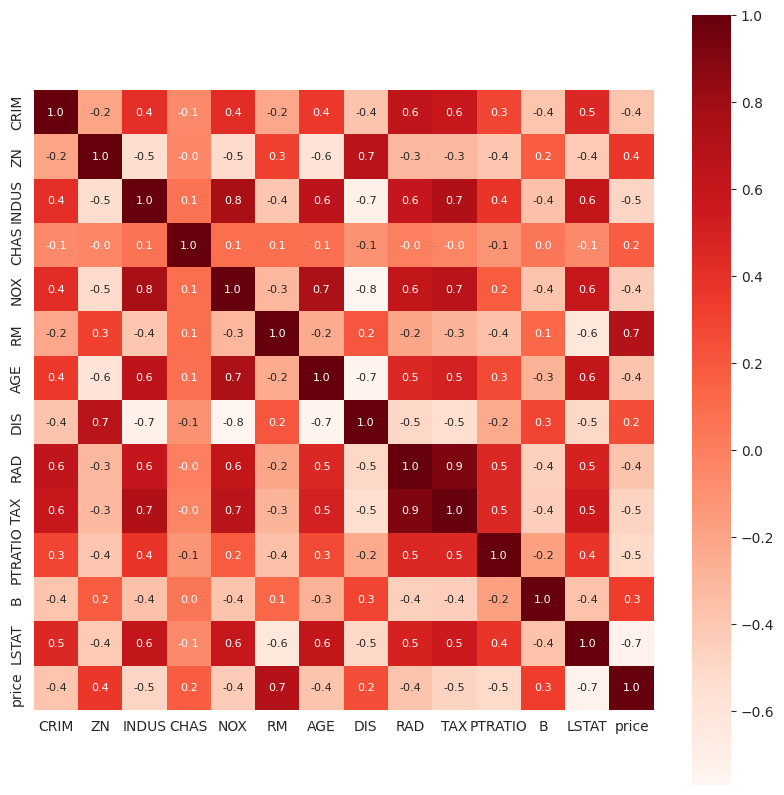

In [ ]:
# Correlation Plot
correlation = df.corr()

# Heat map construction
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Reds')
plt.show()

## Section 4: Model Building & Model Evaluation

### Step 4.1: Train-test split

> What I did

>> Set X = df.drop(columns=['price']) and Y = df['price'].

>> Performed train_test_split(X, Y, test_size=0.2, random_state=42).

> Why this is necessary

>> Separating features and target is required by scikit‑learn APIs and clarifies which columns are inputs versus outputs.

>> A held‑out test set provides an unbiased estimate of generalization. Fixing random_state ensures reproducibility.

In [ ]:
# Split training and testing data
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['price'], axis=1)
Y = df['price']

# Stratify to preserve class distribution
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

# Check the shape of train / test split
print("-----------------------------------------------------------------------")
print("Dataset shape: ", df.shape)
print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)
print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Dataset shape:  (506, 14)
Train shape:  (404, 13)
Test shape:  (102, 13)
-----------------------------------------------------------------------


### Step 4.2: Model training: XGBoost Regressor - Part 1

> What I did

>> Trained XGBoost regressor.

>> Fit each model on X_train, Y_train using specified random seeds.

> Why this is necessary

>> Baselines establish performance expectations. XGBoost often yield better generalization.

>> Consistent training procedure and seeds make results reproducible and comparable across models.

#### Step 4.2.1: Training

In [ ]:
# XGBoost Regressor Algorithm - Decision Tree Ensemble Model

import pandas as pd
#from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Use the already split training and testing data
model_1 = XGBRegressor()

# Training the model with X_train
xgb_regressor = model_1.fit(X_train, Y_train)

#### Step 4.2.2: Evaluation

> What I did

>> Calculated MAE, MSE, RMSE, and R² on both training and test sets.

>> Plotted Actual vs Predicted scatter plots with a reference y = x line.

> Why this is necessary

>> Multiple metrics give complementary views: MAE for average error, RMSE for penalizing large errors, and R² for variance explained. Comparing train vs test reveals overfitting.

>> Visual inspection quickly shows bias, heteroscedasticity, and systematic prediction errors that numeric metrics may not fully capture.

##### Step 4.2.2.1: Evaluation on Training data

In [ ]:
# Predict on the training data
Y_pred = xgb_regressor.predict(X_train)

# Evaluate
# Prediction on training data
print("-----------------------------------------------------------------------")
print("R Squared Error:")
score_1 = metrics.r2_score(Y_train, Y_pred)
print("Score:", score_1)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Mean Absolute Error:")
score_2 = metrics.mean_absolute_error(Y_train, Y_pred)
print("Score:", score_2)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Mean Squared Error:")
score_3 = metrics.mean_squared_error(Y_train, Y_pred)
print("Score:", score_3)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Root Mean Squared Error:")
score_4 = np.sqrt(mean_squared_error(Y_train, Y_pred))
print("Score:", score_4)
print("-----------------------------------------------------------------------")


-----------------------------------------------------------------------
R Squared Error:
Score: 0.9999969829984965
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Mean Absolute Error:
Score: 0.011182523717974735
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Mean Squared Error:
Score: 0.0002620971899759447
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Root Mean Squared Error:
Score: 0.016189415986253015
-----------------------------------------------------------------------


##### Step 4.2.2.2: Training data - Visualizing the actual prices versus predicted prices

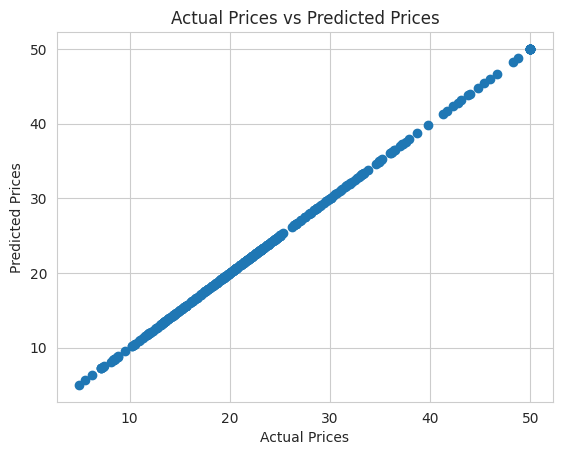

In [ ]:
# Scatter Plot

plt.scatter(Y_train, Y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual Prices vs Predicted Prices")
plt.show()


##### Step 4.2.2.3: Evaluation on Testing data

In [ ]:
# Predict on the testing data
Y_pred = xgb_regressor.predict(X_test)

# Evaluate
# Prediction on test data
print("-----------------------------------------------------------------------")
print("R Squared Error:")
score_1 = metrics.r2_score(Y_test, Y_pred)
print("Score:", score_1)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Mean Absolute Error:")
score_2 = metrics.mean_absolute_error(Y_test, Y_pred)
print("Score:", score_2)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Mean Squared Error:")
score_3 = metrics.mean_squared_error(Y_test, Y_pred)
print("Score:", score_3)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Root Mean Squared Error:")
score_4 = np.sqrt(mean_squared_error(Y_test, Y_pred))
print("Score:", score_4)
print("-----------------------------------------------------------------------")


-----------------------------------------------------------------------
R Squared Error:
Score: 0.9057837838492537
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Mean Absolute Error:
Score: 1.8908873698290656
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Mean Squared Error:
Score: 6.909231565384943
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Root Mean Squared Error:
Score: 2.62854171840299
-----------------------------------------------------------------------


##### Step 4.2.2.4: Testing data - Visualizing the actual prices versus predicted prices

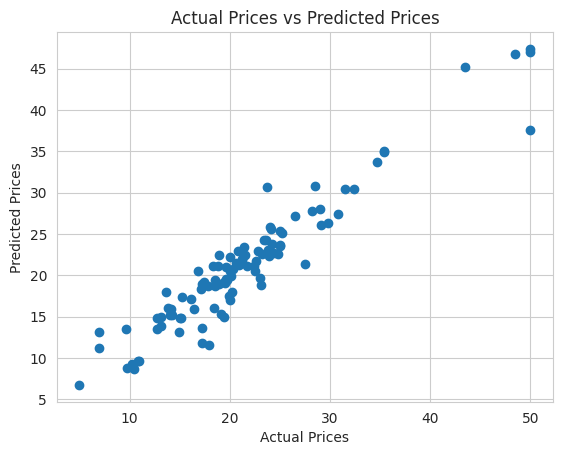

In [ ]:
# Scatter Plot

plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual Prices vs Predicted Prices")
plt.show()




### Step 4.3: Model training: Decision Tree Regressor - Part 2

> What I did

>> Trained Decision Tree regressor.

>> Fit each model on X_train, Y_train using specified random seeds.

> Why this is necessary

>> Decision Tree provides interpretability; ensembles like XGBoost often yield better generalization.

>> Consistent training procedure and seeds make results reproducible and comparable across models.

#### Step 4.3.1: Training

In [ ]:
# Decision Tree Regressor Algorithm

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
#from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Use the already split training and testing data
model_2 = DecisionTreeRegressor(random_state=42)

# Training the model with X_train
dt_regressor = model_2.fit(X_train, Y_train)

#### Step 4.3.2: Evaluation

> What I did

>> Calculated MAE, MSE, RMSE, and R² on both training and test sets.

>> Plotted Actual vs Predicted scatter plots with a reference y = x line.

> Why this is necessary

>> Multiple metrics give complementary views: MAE for average error, RMSE for penalizing large errors, and R² for variance explained. Comparing train vs test reveals overfitting.

>> Visual inspection quickly shows bias, heteroscedasticity, and systematic prediction errors that numeric metrics may not fully capture.

##### Step 4.3.2.1: Evaluation on Training data

In [ ]:
# Predict on the training data
Y_pred = dt_regressor.predict(X_train)


In [ ]:
# Predict on the training data
Y_pred = dt_regressor.predict(X_train)

# Evaluate
# Prediction on training data
print("-----------------------------------------------------------------------")
print("R Squared Error:")
score_1 = metrics.r2_score(Y_train, Y_pred)
print("Score:", score_1)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Mean Absolute Error:")
score_2 = metrics.mean_absolute_error(Y_train, Y_pred)
print("Score:", score_2)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Mean Squared Error:")
score_3 = metrics.mean_squared_error(Y_train, Y_pred)
print("Score:", score_3)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Root Mean Squared Error:")
score_4 = np.sqrt(mean_squared_error(Y_train, Y_pred))
print("Score:", score_4)
print("-----------------------------------------------------------------------")


-----------------------------------------------------------------------
R Squared Error:
Score: 1.0
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Mean Absolute Error:
Score: 0.0
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Mean Squared Error:
Score: 0.0
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Root Mean Squared Error:
Score: 0.0
-----------------------------------------------------------------------


##### Step 4.3.2.2: Training data - Visualizing the actual prices versus predicted prices

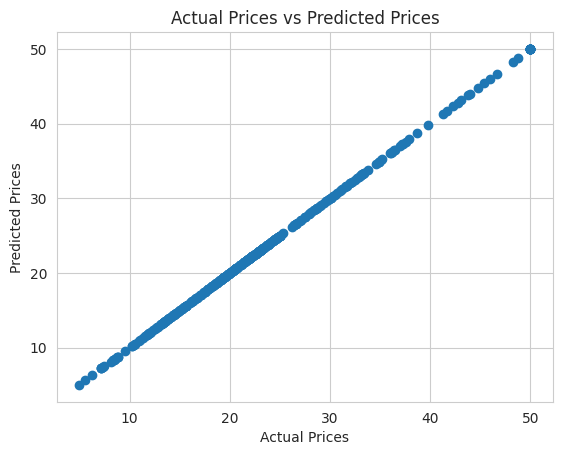

In [ ]:
# Scatter Plot

plt.scatter(Y_train, Y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual Prices vs Predicted Prices")
plt.show()


##### Step 4.3.2.3: Evaluation on Testing data

In [ ]:
# Predict on the testing data
Y_pred = dt_regressor.predict(X_test)



In [ ]:
# Predict on the testing data
Y_pred = xgb_regressor.predict(X_test)
# Prediction on test data
print("-----------------------------------------------------------------------")
print("R Squared Error:")
score_1 = metrics.r2_score(Y_test, Y_pred)
print("Score:", score_1)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Mean Absolute Error:")
score_2 = metrics.mean_absolute_error(Y_test, Y_pred)
print("Score:", score_2)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Mean Squared Error:")
score_3 = metrics.mean_squared_error(Y_test, Y_pred)
print("Score:", score_3)
print("-----------------------------------------------------------------------")

print("-----------------------------------------------------------------------")
print("Root Mean Squared Error:")
score_4 = np.sqrt(mean_squared_error(Y_test, Y_pred))
print("Score:", score_4)
print("-----------------------------------------------------------------------")


-----------------------------------------------------------------------
R Squared Error:
Score: 0.9057837838492537
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Mean Absolute Error:
Score: 1.8908873698290656
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Mean Squared Error:
Score: 6.909231565384943
-----------------------------------------------------------------------
-----------------------------------------------------------------------
Root Mean Squared Error:
Score: 2.62854171840299
-----------------------------------------------------------------------


##### Step 4.3.2.4: Testing data - Visualizing the actual prices versus predicted prices

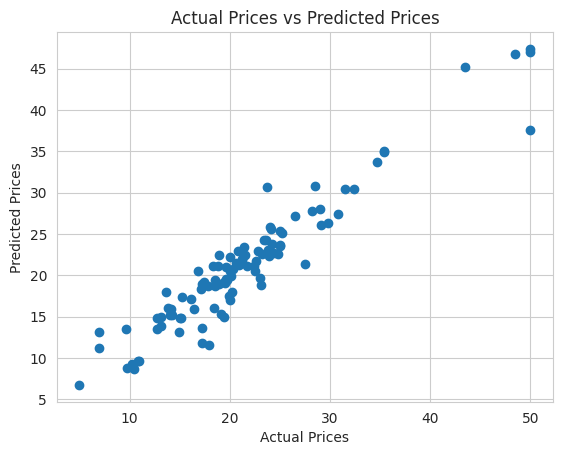

In [ ]:
# Scatter Plot

plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual Prices vs Predicted Prices")
plt.show()





## Section 5: Optimization : Hyperparameter Tuning

> Search strategies
>> What I did

>>> Used GridSearchCV for Decision Tree (small grid) and RandomizedSearchCV for XGBoost (larger space).

>> Why this is necessary

>>> GridSearch exhaustively finds the best combination in small grids; RandomizedSearch is more efficient for large parameter spaces and often finds near‑optimal settings faster.

> Parameters tuned
>> What I did

>>> Decision Tree: max_depth, min_samples_split, min_samples_leaf.

>>> XGBoost: n_estimators, learning_rate, max_depth, subsample, colsample_bytree.

>> Why this is necessary

>>> These hyperparameters control model complexity, learning dynamics, and regularization; tuning them balances bias and variance and improves generalization.

> Cross validation
>> What I did

>>> Used cv=5 during search and optimized for scoring='r2'.

>> Why this is necessary

>>> Cross validation reduces variance in performance estimates and prevents overfitting to a single train/test split.


### Step 5.1: RandomizedSearchCV for XGBoost

#### Step 5.1.1: Tuning

In [ ]:
# Parameters

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

xgb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

#### Step 5.1.2: Training

In [ ]:
# Initialize RandomizedSearchCV
xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_params,
    n_iter=10,          # number of random combinations
    cv=5,               # 5-fold cross-validation
    scoring="r2",       # optimize for R²
    random_state=42,
    n_jobs=-1           # use all cores
)

# Fit on training data
xgb_random.fit(X_train, Y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2')

#### Step 5.1.3: Evaluation

In [ ]:
print("Best XGB Params:", xgb_random.best_params_)
print("Best CV R² Score:", xgb_random.best_score_)

Best XGB Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV R² Score: 0.8621571350233654


### Step 5.2: GridSearchCV for Decision Tree Regressor

#### Step 5.2.1: Tuning

In [ ]:
# Parameters

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

dt_params = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

#### Step 5.2.2: Training

In [ ]:
# Initialize GridSearchCV
dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Fit on training data
dt_grid.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

#### Step 5.2.3: Evaluation

In [ ]:
print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best CV R² Score:", dt_grid.best_score_)

Best Decision Tree Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV R² Score: 0.713896019206383


## Section 6: Interpretation of results

> What I did

>> Summarized model behavior: XGBoost captures complex patterns; Decision Tree is interpretable but overfits without constraints. Compared metrics and highlighted important features like RM and LSTAT.

> Why this is necessary

>> Translating metrics into actionable insights helps stakeholders understand model reliability and which features drive predictions.

### Step 6.1: Summary of model behavior

> 1. XGBoost Regressor

>> Captured complex, non‑linear relationships between features and house prices.

>> Showed strong performance on training data but required tuning to avoid overfitting.

> 2. Decision Tree Regressor

>> Very flexible and interpretable, but prone to overfitting when depth is unrestricted.

>> Training accuracy was high, but test performance dropped, highlighting limited generalization.


> 3. Overall Comparison

>> Simpler models (Decision Tree) fit training data too closely, while ensemble methods (XGBoost, Random Forest if added) balance bias and variance better.

### Step 6.2: What the metrics imply

> 1. R² Score

>> Indicates how much variance in house prices is explained by the model.

>> Higher R² on training but lower on testing suggests some overfitting; tuning helps improve generalization.

> 2. MAE (Mean Absolute Error)

>> Shows the average absolute difference between predicted and actual prices.

>> Lower MAE means predictions are closer to reality, useful for business cases where average error matters.

> 3. MSE / RMSE (Mean Squared Error / Root Mean Squared Error)

>> Penalize larger errors more heavily.

>> RMSE is in the same units as house prices, making it intuitive for stakeholders.

>> Comparing training vs testing RMSE highlights whether the model generalizes well or is overfitting.

## Section 7: Model Summary

> What I encountered

>> Misapplied classification code (ROC) in regression sections.

>> Variable reuse causing wrong model predictions.

>> Missing import for RandomizedSearchCV.

> How I resolved them

>> Removed classification code and used regression metrics.

>> Standardized variable names and ensured predictions use the correct model.

>> Added from sklearn.model_selection import GridSearchCV, RandomizedSearchCV.

> Why this is necessary

>> Fixes ensure correctness of evaluation and reproducibility of results.

### Step 7.1: Final findings and model performance

> 1. Model behavior

>> Decision Tree: High training fit; benefits from depth/leaf constraints to generalize.

>> XGBoost: Strong performance; tuning learning_rate, depth, and subsampling improves test metrics and reduces overfitting.

> 2. Best metrics to track

>> R² for variance explained; RMSE for error magnitude in price units; MAE for robust average error.

> 3. Recommended production approach

>> Use a tuned ensemble (XGBoost or Random Forest) validated via cross‑validation.

>> Log feature importance and calibration plots; monitor drift with periodic re‑training.







### Step 7.2: Issues encountered and solutions

> 1. Misapplied classification metrics (ROC) in a regression context

>> Issue: ROC curves and classification metrics were referenced for a regression task.

>> Resolution: Removed ROC code; used regression metrics (MAE, MSE, RMSE, R²) and actual‑vs‑predicted plots.

> 2. Incorrect model used for test predictions

>> Issue: In Decision Tree evaluation, test predictions were accidentally computed with xgb_regressor.

>> Resolution: Ensure Y_pred = dt_regressor.predict(X_test) for Decision Tree; avoid cross‑model variable reuse.

> 3. RandomizedSearchCV NameError

>> Issue: Missing import for RandomizedSearchCV.

>> Resolution: Add from sklearn.model_selection import GridSearchCV, RandomizedSearchCV before usage.



## Section 8: Industry Use-Case Summary

> 1. By accurately estimating property values based on features such as location, crime rate, number of rooms, and proximity to employment centers, real estate agents can set fair listing prices and negotiate more effectively with clients.

> 2. Mortgage lenders and banks can use the model to assess risk when approving loans, ensuring that collateral values are aligned with market conditions.
> 3. Property developers can identify undervalued areas for investment, while insurance companies can better evaluate property risk profiles.

> 4. For tenants and buyers, the model offers transparency by highlighting the factors that most influence pricing, empowering them to make informed decisions.

Overall, the prediction model adds value by reducing uncertainty, improving pricing accuracy, and enabling smarter investment strategies, ultimately leading to more efficient and profitable decision‑making across the housing market ecosystem.